In [1]:
import os
import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import pickle

In [2]:
ls

For KMeds.sql                    for campaign - companies.sql
GST predictions.csv              for campaign - users.sql
GTV by payment type combos.sql   for campaign.sql
Python codes - clustering.ipynb  for regression.sql
Python codes - regression.ipynb  kmeans_model.pkl
Unmanaged.code-workspace         kmedoids_model.pkl
for EDA.sql                      scratch.sql


In [5]:
# Get SQL query file as data input 
def get_sql_file_as_text(file_path):
  
  with open(file_path, 'r') as f:
    sql_content = f.read()
  return sql_content

In [4]:
# Establish connection with Snowflake
conn = snowflake.connector.connect(connection_name="fundingsociety.sg.ap-southeast-1.aws.privatelink")

In [6]:
# Write SQL Snowflake Query here
sql_file = "For KMeds.sql"
sql_text = get_sql_file_as_text(sql_file)

my_query=sql_text

In [7]:
# Get data from query above
results = conn.cursor().execute(my_query).fetch_pandas_all()

In [8]:
# Check data
results.head()

,COMPANY_ID,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
0,1825,375,39,2.181818,253.416614680000,0.000000
1,4213,201,20,32.000000,35435.468641173333,0.000000
2,3355,354,19,3.272727,1329.092405600000,0.000000
3,3958,263,139,1.250000,2884.902625000000,1.000000
4,3304,380,16,83.454545,51590.299773560000,0.000000


In [9]:
results.shape

(841, 6)

In [10]:
# Set index
results = results.set_index('COMPANY_ID')
results.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
COMPANY_ID,,,,,
1825,375,39,2.181818,253.416614680000,0.000000
4213,201,20,32.000000,35435.468641173333,0.000000
3355,354,19,3.272727,1329.092405600000,0.000000
3958,263,139,1.250000,2884.902625000000,1.000000
3304,380,16,83.454545,51590.299773560000,0.000000


In [11]:
# Change types from object to float
results.AVG_MONTHLY_PAYMENT_COUNT = results.AVG_MONTHLY_PAYMENT_COUNT.astype(float)
results.AVG_MONTHLY_PAYMENTS = results.AVG_MONTHLY_PAYMENTS.astype(float)
results.PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING = results.PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING.astype(float)

In [12]:
# Get sumstats
results.describe()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
count,841.000000,841.000000,841.000000,8.410000e+02,841.000000
mean,290.687277,50.111772,4.627518,1.683528e+04,0.138120
std,99.696843,44.156587,15.066983,5.607486e+04,0.261231
min,16.000000,16.000000,0.181818,7.444910e-01,0.000000
25%,227.000000,19.000000,1.090909,2.977964e+03,0.000000
50%,341.000000,31.000000,1.750000,7.019611e+03,0.000000
75%,370.000000,62.000000,3.444444,1.682518e+04,0.150000
max,380.000000,346.000000,343.181818,1.302734e+06,1.000000


In [13]:
# Transform data
results_transformed = results.copy()
results_transformed['DAYS_SINCE_FIRST_TX'] = np.log((390 - results_transformed['DAYS_SINCE_FIRST_TX']))
# results_transformed['DAYS_SINCE_FIRST_TX'] = (390 - results_transformed['DAYS_SINCE_FIRST_TX'])
results_transformed['DAYS_SINCE_LAST_TX'] = np.log1p(results_transformed['DAYS_SINCE_LAST_TX'])
results_transformed['AVG_MONTHLY_PAYMENT_COUNT'] = np.log1p(results_transformed['AVG_MONTHLY_PAYMENT_COUNT'])
results_transformed['AVG_MONTHLY_PAYMENTS'] = np.log1p(results_transformed['AVG_MONTHLY_PAYMENTS'])

# Check data again
results_transformed.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
COMPANY_ID,,,,,
1825,2.708050,3.688879,1.157453,5.538973,0.0
4213,5.241747,3.044522,3.496508,10.475497,0.0
3355,3.583519,2.995732,1.452252,7.193004,0.0
3958,4.844187,4.941642,0.810930,7.967593,1.0
3304,2.302585,2.833213,4.436213,10.851108,0.0


In [14]:
# Sumstats new data
results_transformed.describe()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
count,841.000000,841.000000,841.000000,841.000000,841.000000
mean,4.008396,3.645750,1.226611,8.800299,0.138120
std,1.147772,0.720308,0.752076,1.396132,0.261231
min,2.302585,2.833213,0.167054,0.556463,0.000000
25%,2.995732,2.995732,0.737599,7.999331,0.000000
50%,3.891820,3.465736,1.011601,8.856605,0.000000
75%,5.093750,4.143135,1.491655,9.730691,0.150000
max,5.924256,5.849325,5.841170,14.079976,1.000000


In [15]:
# Robust Scaler
scaler = RobustScaler()
results_transformed_scaled = pd.DataFrame(scaler.fit_transform(results_transformed), columns=results_transformed.columns, index=results_transformed.index)
results_transformed_scaled.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
COMPANY_ID,,,,,
1825,-0.564233,0.194477,0.193423,-1.916200,0.000000
4213,0.643430,-0.367102,3.295388,0.935040,0.000000
3355,-0.146949,-0.409624,0.584375,-0.960864,0.000000
3958,0.453936,1.286302,-0.266122,-0.513476,6.666667
3304,-0.757494,-0.551265,4.541590,1.151986,0.000000


In [16]:
# Scaled dataset describe
results_transformed_scaled.describe()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
count,841.000000,841.000000,841.000000,841.000000,841.000000
mean,0.055565,0.156888,0.285138,-0.032521,0.920803
std,0.547074,0.627772,0.997374,0.806378,1.741537
min,-0.757494,-0.551265,-1.120006,-4.794000,0.000000
25%,-0.427112,-0.409624,-0.363371,-0.495145,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.572888,0.590376,0.636629,0.504855,1.000000
max,0.968741,2.077378,6.404789,3.016917,6.666667


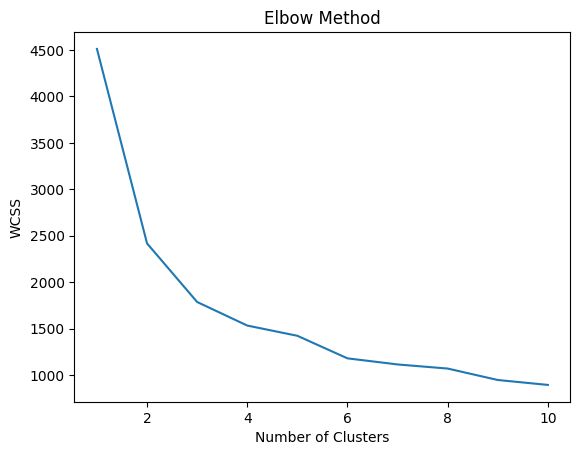

In [18]:
# Determine the optimal number of clusters using the Elbow method - KMeans
wcss = []
for i in range(1, 11):
    km2 = KMeans(n_clusters=i, random_state=42)
    km2.fit(results_transformed_scaled)
    wcss.append(km2.inertia_)

# Plot the Elbow method graph
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [20]:
km2 = KMeans(4)
c2 = km2.fit(results_transformed_scaled)
print("Loss is:", c2.inertia_)

Loss is: 1532.0559746374095


In [22]:
results['cluster_kmeans'] = km2.labels_
results.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING,cluster,cluster_kmeans
COMPANY_ID,,,,,,,
1825,375,39,2.181818,253.416615,0.0,2,0
4213,201,20,32.000000,35435.468641,0.0,0,2
3355,354,19,3.272727,1329.092406,0.0,1,3
3958,263,139,1.250000,2884.902625,1.0,3,1
3304,380,16,83.454545,51590.299774,0.0,0,2


In [24]:
# Save model

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump((km2, km2.labels_), f)

In [26]:
# Load model
with open('kmeans_model.pkl', 'rb') as f:
    km2, labels2 = pickle.load(f)

# new_data_labels = km2.predict(new_data)

In [27]:
# Sample New Data

# new_data_label = pd.DataFrame()
# new_data_label['cluster'] = pd.DataFrame(km.predict(results_transformed_scaled.drop(columns='cluster')))
# new_data_label.index = results_transformed_scaled.index
# new_data_label = new_data_label.reset_index()
# new_data_label.head()

In [28]:
# Export to SQL for EDA

cursor = conn.cursor()
cursor.execute("""
DROP TABLE IF EXISTS DEV.SBOX_SHILTON.TEST_CLUSTERING_RESULTS;
""")

# Commit the changes
conn.commit()

df_export_cluster = pd.DataFrame(results[['cluster', 'cluster_kmeans']])
df_export_cluster = df_export_cluster.reset_index()
df_export_cluster.head()

df_export_cluster.columns = df_export_cluster.columns.str.upper()

write_pandas(
    conn,
    df_export_cluster,
    table_name='TEST_CLUSTERING_RESULTS',
    database='DEV',
    schema='SBOX_SHILTON',
    auto_create_table=True)

(True,
 1,
 841,
 [('pxrgzxhjcp/file0.txt', 'LOADED', 841, 841, 1, 0, None, None, None, None)])

In [29]:
results.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING,cluster,cluster_kmeans
COMPANY_ID,,,,,,,
1825,375,39,2.181818,253.416615,0.0,2,0
4213,201,20,32.000000,35435.468641,0.0,0,2
3355,354,19,3.272727,1329.092406,0.0,1,3
3958,263,139,1.250000,2884.902625,1.0,3,1
3304,380,16,83.454545,51590.299774,0.0,0,2


In [31]:
# Group the data by the cluster label and calculate summary statistics
summary_stats2 = results.groupby('cluster_kmeans').agg(['count', 'mean', 'median', 'std', 'min', 'max'])

# Print the summary statistics for each cluster
summary_stats2

DAYS_SINCE_FIRST_TX                                          \
                             count        mean median         std min  max   
cluster_kmeans                                                               
0                              269  269.784387  305.0  101.528018  17  380   
1                              127  295.094488  349.0   92.739731  30  380   
2                              106  312.075472  370.0  100.988891  18  380   
3                              339  298.935103  355.0   97.914867  16  380   

               DAYS_SINCE_LAST_TX                                        \
                            count       mean median        std min  max   
cluster_kmeans                                                            
0                             269  81.152416   69.0  49.645412  16  346   
1                             127  41.921260   26.0  39.175552  16  191   
2                             106  29.188679   18.5  30.996502  16  234   
3                             339  35.091445   24.0  29.415115  16  192   

               AVG_MONTHLY_PAYMENT_COUNT                                   \
                                   count       mean     median        std   
cluster_kmeans                                                              
0                                    269   1.145757   1.000000   0.707605   
1                                    127   2.416062   1.363636   2.836925   
2                                    106  22.617190  12.145454  37.708402   
3                                    339   2.593723   2.272727   1.389515   

                                     AVG_MONTHLY_PAYMENTS                \
                     min         max                count          mean   
cluster_kmeans                                                            
0               0.181818    6.125000                  269   3812.928994   
1               0.300000   23.090909                  127  13221.917747   
2               5.363636  343.181818                  106  49026.452235   
3               0.500000    6.833333                  339  18456.641887   

                                                                        \
                      median            std          min           max   
cluster_kmeans                                                           
0                2545.307708    4203.387097     0.744491  2.547387e+04   
1                7444.910000   25153.755817   744.366918  2.590502e+05   
2               26405.327604  130945.485082  1929.551469  1.302734e+06   
3               11110.785545   42076.774587   877.957932  7.072664e+05   

               PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING                      \
                                                  count      mean    median   
cluster_kmeans                                                                
0                                                   269  0.018412  0.000000   
1                                                   127  0.697716  0.666667   
2                                                   106  0.023316  0.000000   
3                                                   339  0.059366  0.000000   

                                             cluster                   \
                     std       min       max   count      mean median   
cluster_kmeans                                                          
0               0.062780  0.000000  0.375000     269  1.914498    2.0   
1               0.203925  0.388889  1.000000     127  3.000000    3.0   
2               0.061715  0.000000  0.406250     106  0.000000    0.0   
3               0.101799  0.000000  0.377778     339  1.064897    1.0   

                                  
                     std min max  
cluster_kmeans                    
0               0.293165   1   3  
1               0.000000   3   3  
2               0.000000   0   0  
3               0.528961   0   3

In [32]:
results_transformed_scaled['cluster_kmeans'] = km2.labels_
results_transformed_scaled.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING,cluster,cluster_kmeans
COMPANY_ID,,,,,,,
1825,-0.564233,0.194477,0.193423,-1.916200,0.000000,2,0
4213,0.643430,-0.367102,3.295388,0.935040,0.000000,0,2
3355,-0.146949,-0.409624,0.584375,-0.960864,0.000000,1,3
3958,0.453936,1.286302,-0.266122,-0.513476,6.666667,3,1
3304,-0.757494,-0.551265,4.541590,1.151986,0.000000,0,2
